In [2]:
import matplotlib.pyplot as plt
import numpy as np
import pickle 
from matplotlib.animation import FuncAnimation
from IPython.display import HTML
import statistics

In [148]:
with open('Nov18/v10_175_p3_n0_d50_n10000_NoZ.pkl', 'rb') as f:
    loaded_dict = pickle.load(f)

In [149]:
# with open('Nov15/v10_175_p3_n6_d005_n10000_NoZ.pkl', 'rb') as f:
#     loaded_dict2 = pickle.load(f)

In [150]:
keysList = [key for key in loaded_dict]
# keysList2 = [key for key in loaded_dict2]
# print(keysList[0],len(keysList))

In [151]:
keyListshort = keysList[::1]
bins = int(np.sqrt(len(keyListshort)))

In [104]:
varianceList = []

energyArrays = [np.array(loaded_dict[key].energy() / loaded_dict[key].energy().unit)
    for key in keyListshort]

energyMatrix = np.array(energyArrays)

varianceList = [statistics.variance(row) for row in energyMatrix.T]

In [94]:
# varianceList2 = []

# energyArrays2 = [np.array(loaded_dict2[key].energy() / loaded_dict2[key].energy().unit)
#     for key in keysList2]

# energyMatrix2 = np.array(energyArrays2)

# varianceList2 = [statistics.variance(row) for row in energyMatrix2.T]

In [95]:
# np.save('Nov12/v10_175_p3_n6_d50_n100_VAR.npy',varianceList)

In [96]:
rangeVarianceList = [n*0.05 for n in list(range(len(varianceList)))]
# rangeVarianceList2 = [n*0.005 for n in list(range(len(varianceList2)))]

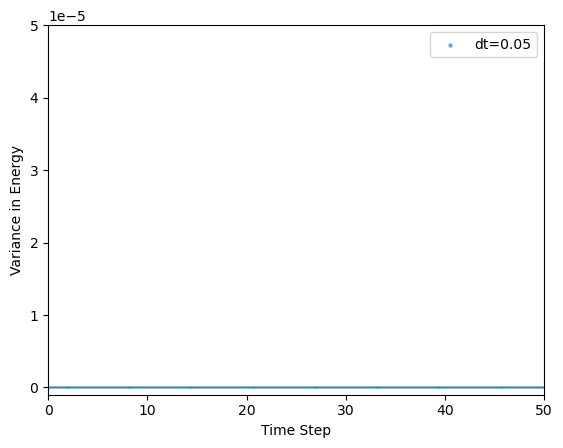

In [98]:
plt.scatter(rangeVarianceList,varianceList,s=0.2,alpha=0.5,label = 'dt=0.05')
# plt.scatter(rangeVarianceList2,varianceList2,s=0.2,alpha=0.5,label="dt=0.005")
plt.ylabel('Variance in Energy')
plt.xlabel('Time Step')
plt.xlim(0,50)
plt.ylim(-0.000001,0.00005)
plt.legend(markerscale= 5)
plt.show()

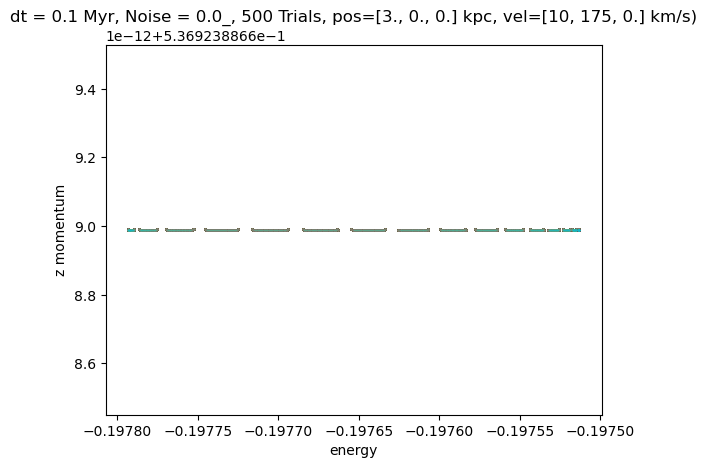

In [152]:
length = loaded_dict[keysList[0]].energy().shape[0] + 1

keyListshort = keysList[::1]

for i in keyListshort:
    # components = loaded_dict[i].pos.components[0]
    #x, labels = loaded_dict[i]._plot_prepare(components=components, units=None)
    energy = loaded_dict[i].energy()
    momentum = loaded_dict[i].angular_momentum()[2]
    plt.scatter(energy, momentum, s = 0.15, alpha = 0.2)

#plt.legend(markerscale = 5, loc='lower right')
plt.ylabel('z momentum')
plt.xlabel('energy')
plt.title(f'dt = 5 Myr, Noise = {str(keysList[0][:4])}, {len(keysList)} Trials, pos=[3., 0., 0.] kpc, vel=[10, 175, 0.] km/s)')
# plt.savefig('Nov11/EnergyVsZMomentum_N'+str(keysList[0][:4])+'.png')
plt.show()

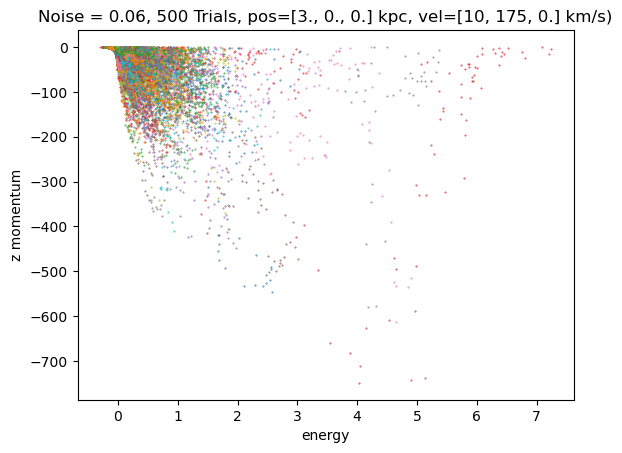

In [58]:
keyListshort = keysList[::1]
decreasingZs = {}
decreasingZcounts = 0

for i in keyListshort:
    energy = loaded_dict[i].energy()
    momentum = loaded_dict[i].angular_momentum()[2]
    mask = momentum < 0
    if np.any(mask):
        decreasingZcounts += 1
        decreasingZs[i] = loaded_dict[i]
        plt.scatter(energy[mask], momentum[mask],s = 0.15)

plt.ylabel('z momentum')
plt.xlabel('energy')
plt.title(f'Noise = {str(keysList[0][:4])}, {len(keysList)} Trials, pos=[3., 0., 0.] kpc, vel=[10, 175, 0.] km/s)')
# plt.savefig('Nov11/EnergyVsMomentum_N'+str(keysList[0][:4])+'.png')
plt.show()

In [59]:
with open('FractionKicks/Nov12_v10_175_p3_n6_d50_n100.pkl', 'wb') as f:
    pickle.dump(decreasingZs, f)

In [60]:
len(decreasingZs)

493

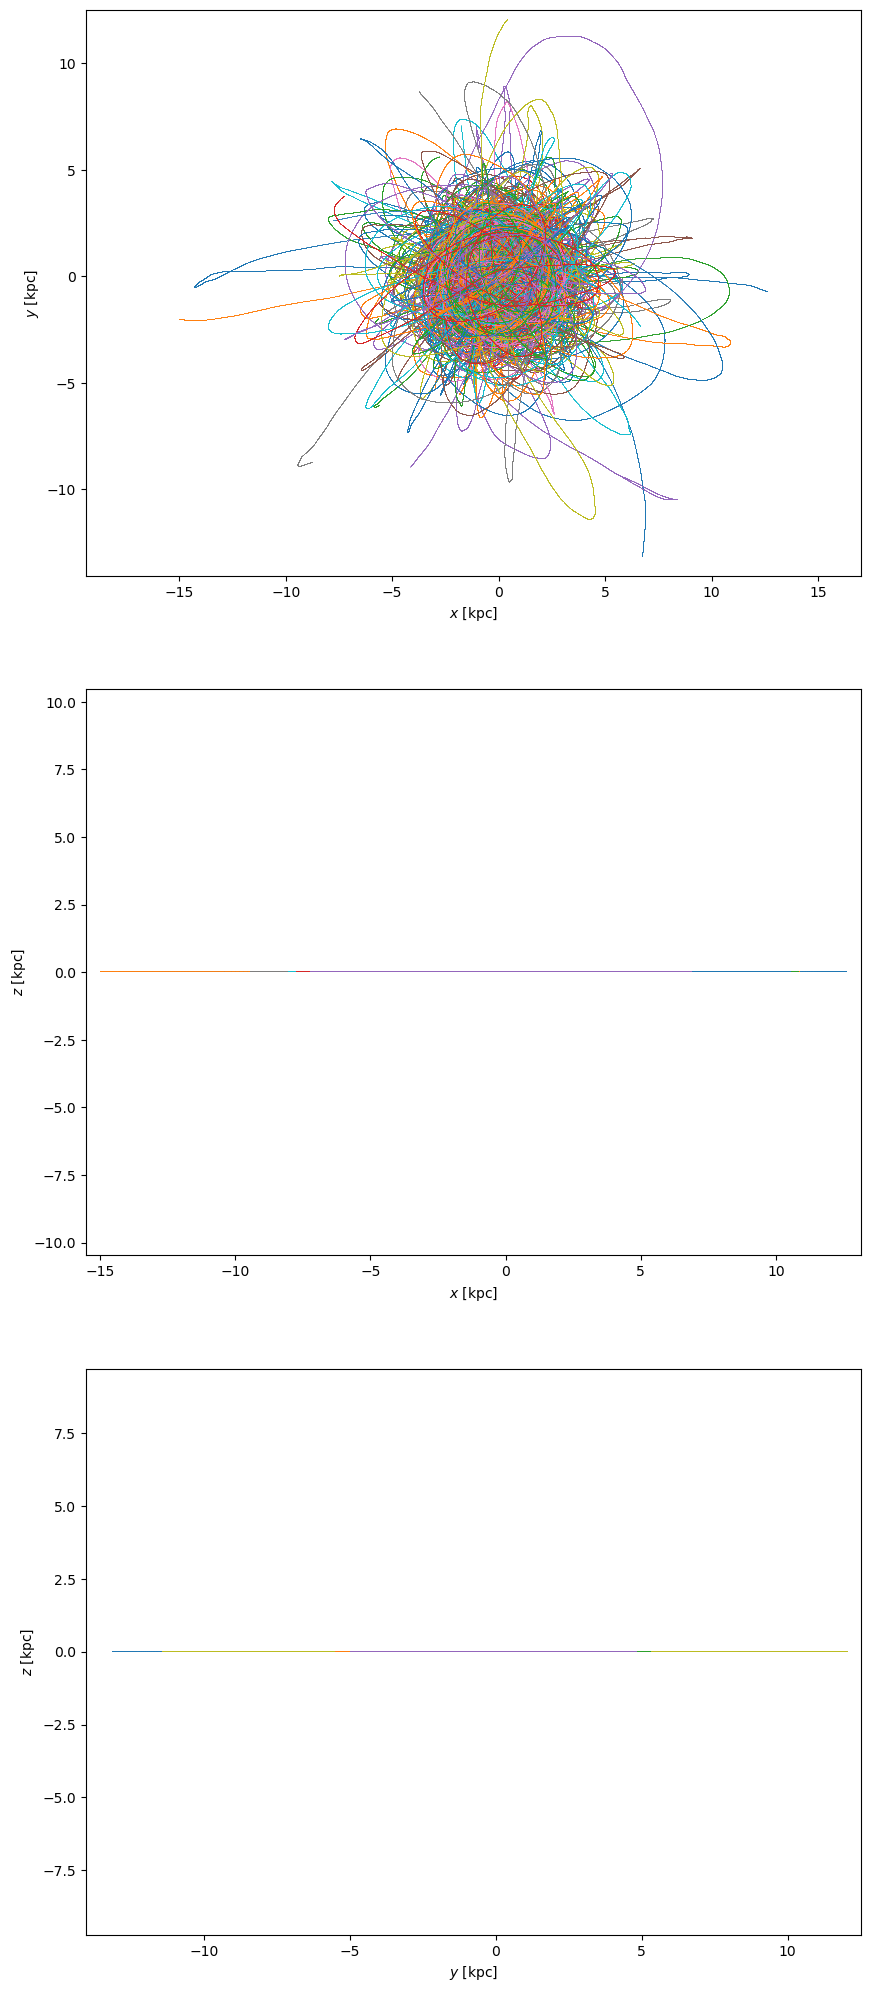

In [57]:
fig, ax = plt.subplots(3,1, figsize = (10,25))

ZkeysList = [key for key in decreasingZs]
ZkeysListshort = ZkeysList[::1]

for i in ZkeysListshort:
    decreasingZs[i].plot(marker=',', linestyle='none', alpha=0.6, axes = ax)

plt.show()